In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── LOAD ──────────────────────────────────────────────────
# House prices dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df  = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.describe().round(2))
print("\nMissing:")
print(df.isnull().sum())

(506, 14)
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object
         crim      zn   indus    chas     nox      rm     age     dis     rad  

In [3]:
# ── CLEAN ─────────────────────────────────────────────────
df_clean = df.copy()

# No missing values in this dataset
# Check and remove outliers in target column (medv = house price)
Q1    = df_clean["medv"].quantile(0.25)
Q3    = df_clean["medv"].quantile(0.75)
IQR   = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

print(f"Price bounds: {lower:.1f} to {upper:.1f}")
print(f"Outliers: {len(df_clean[(df_clean['medv'] < lower) | (df_clean['medv'] > upper)])}")

df_clean = df_clean[
    (df_clean["medv"] >= lower) &
    (df_clean["medv"] <= upper)
]
print(f"Shape after outlier removal: {df_clean.shape}")

Price bounds: 5.1 to 37.0
Outliers: 40
Shape after outlier removal: (466, 14)


In [5]:
# ── FEATURE ENGINEERING ───────────────────────────────────

# Target column: medv = median house price in $1000s
# Features: crime rate, rooms, pollution, school quality etc
# Goal: understand what factors affect house prices


# PriceCategory — buckets house prices into 4 groups
df_clean["PriceCategory"] = pd.cut(
    df_clean["medv"],
    bins   = [0, 15, 25, 35, 100],
    labels = ["Low","Medium","High","VeryHigh"]
)

# High crime area (binary flag 0 or 1)
df_clean["HighCrime"] = (df_clean["crim"] > df_clean["crim"].median()).astype(int)

# Room category
df_clean["RoomCategory"] = pd.cut(
    df_clean["rm"],
    bins   = [0, 5.5, 6.5, 10],
    labels = ["Small","Medium","Large"]
)

print(df_clean[["medv","PriceCategory","HighCrime","RoomCategory"]].head(10))

   medv PriceCategory  HighCrime RoomCategory
0  24.0        Medium          0        Large
1  21.6        Medium          0       Medium
2  34.7          High          0        Large
3  33.4          High          0        Large
4  36.2      VeryHigh          0        Large
5  28.7          High          0       Medium
6  22.9        Medium          0       Medium
7  27.1          High          0       Medium
8  16.5        Medium          0       Medium
9  18.9        Medium          0       Medium


In [11]:
# EDA — EXPLORATORY DATA ANALYSIS

# We calculate correlation of every feature WITH the target (medv)

# Correlation with target
corr = df_clean.corr(numeric_only=True)["medv"].sort_values(ascending=False)
print("Correlation with House Price:")
print(corr.round(3))

# Top features
print("\nTop 5 positive correlators with price:")
print(corr.head(6))
print("\nTop 5 negative correlators with price:")
print(corr.tail(5))

# Price by category
print("\nAverage price per category:")
print(df_clean.groupby("PriceCategory", observed=True)["medv"].agg(["mean","count"]).round(2))

# Room size vs price
print("\nAverage price by room size:")
print(df_clean.groupby("RoomCategory", observed=True)["medv"].mean().round(2))

# Crime impact
print("\nAverage price — High vs Low Crime:")
print(df_clean.groupby("HighCrime")["medv"].mean().round(2))

Correlation with House Price:
medv         1.000
rm           0.569
dis          0.440
zn           0.436
b            0.408
chas         0.097
HighCrime   -0.480
crim        -0.482
ptratio     -0.489
rad         -0.504
age         -0.557
nox         -0.569
tax         -0.590
indus       -0.612
lstat       -0.772
Name: medv, dtype: float64

Top 5 positive correlators with price:
medv    1.000000
rm      0.568940
dis     0.439844
zn      0.436177
b       0.408316
chas    0.097053
Name: medv, dtype: float64

Top 5 negative correlators with price:
age     -0.557098
nox     -0.569014
tax     -0.590236
indus   -0.612220
lstat   -0.772285
Name: medv, dtype: float64

Average price per category:
                mean  count
PriceCategory              
Low            11.85     95
Medium         20.68    285
High           29.96     76
VeryHigh       35.85     10

Average price by room size:
RoomCategory
Small     14.58
Medium    19.21
Large     26.79
Name: medv, dtype: float64

Average price — H

/var/folders/z7/tn5dd55d5t94pm31kl0kd6y00000gn/T/ipykernel_89451/3576977386.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_price, x="RoomCategory", y="medv",
/var/folders/z7/tn5dd55d5t94pm31kl0kd6y00000gn/T/ipykernel_89451/3576977386.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crime_price, x="HighCrime", y="medv",
/var/folders/z7/tn5dd55d5t94pm31kl0kd6y00000gn/T/ipykernel_89451/3576977386.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="PriceCategory",


Text(0.5, 0, 'Average Number of Rooms')

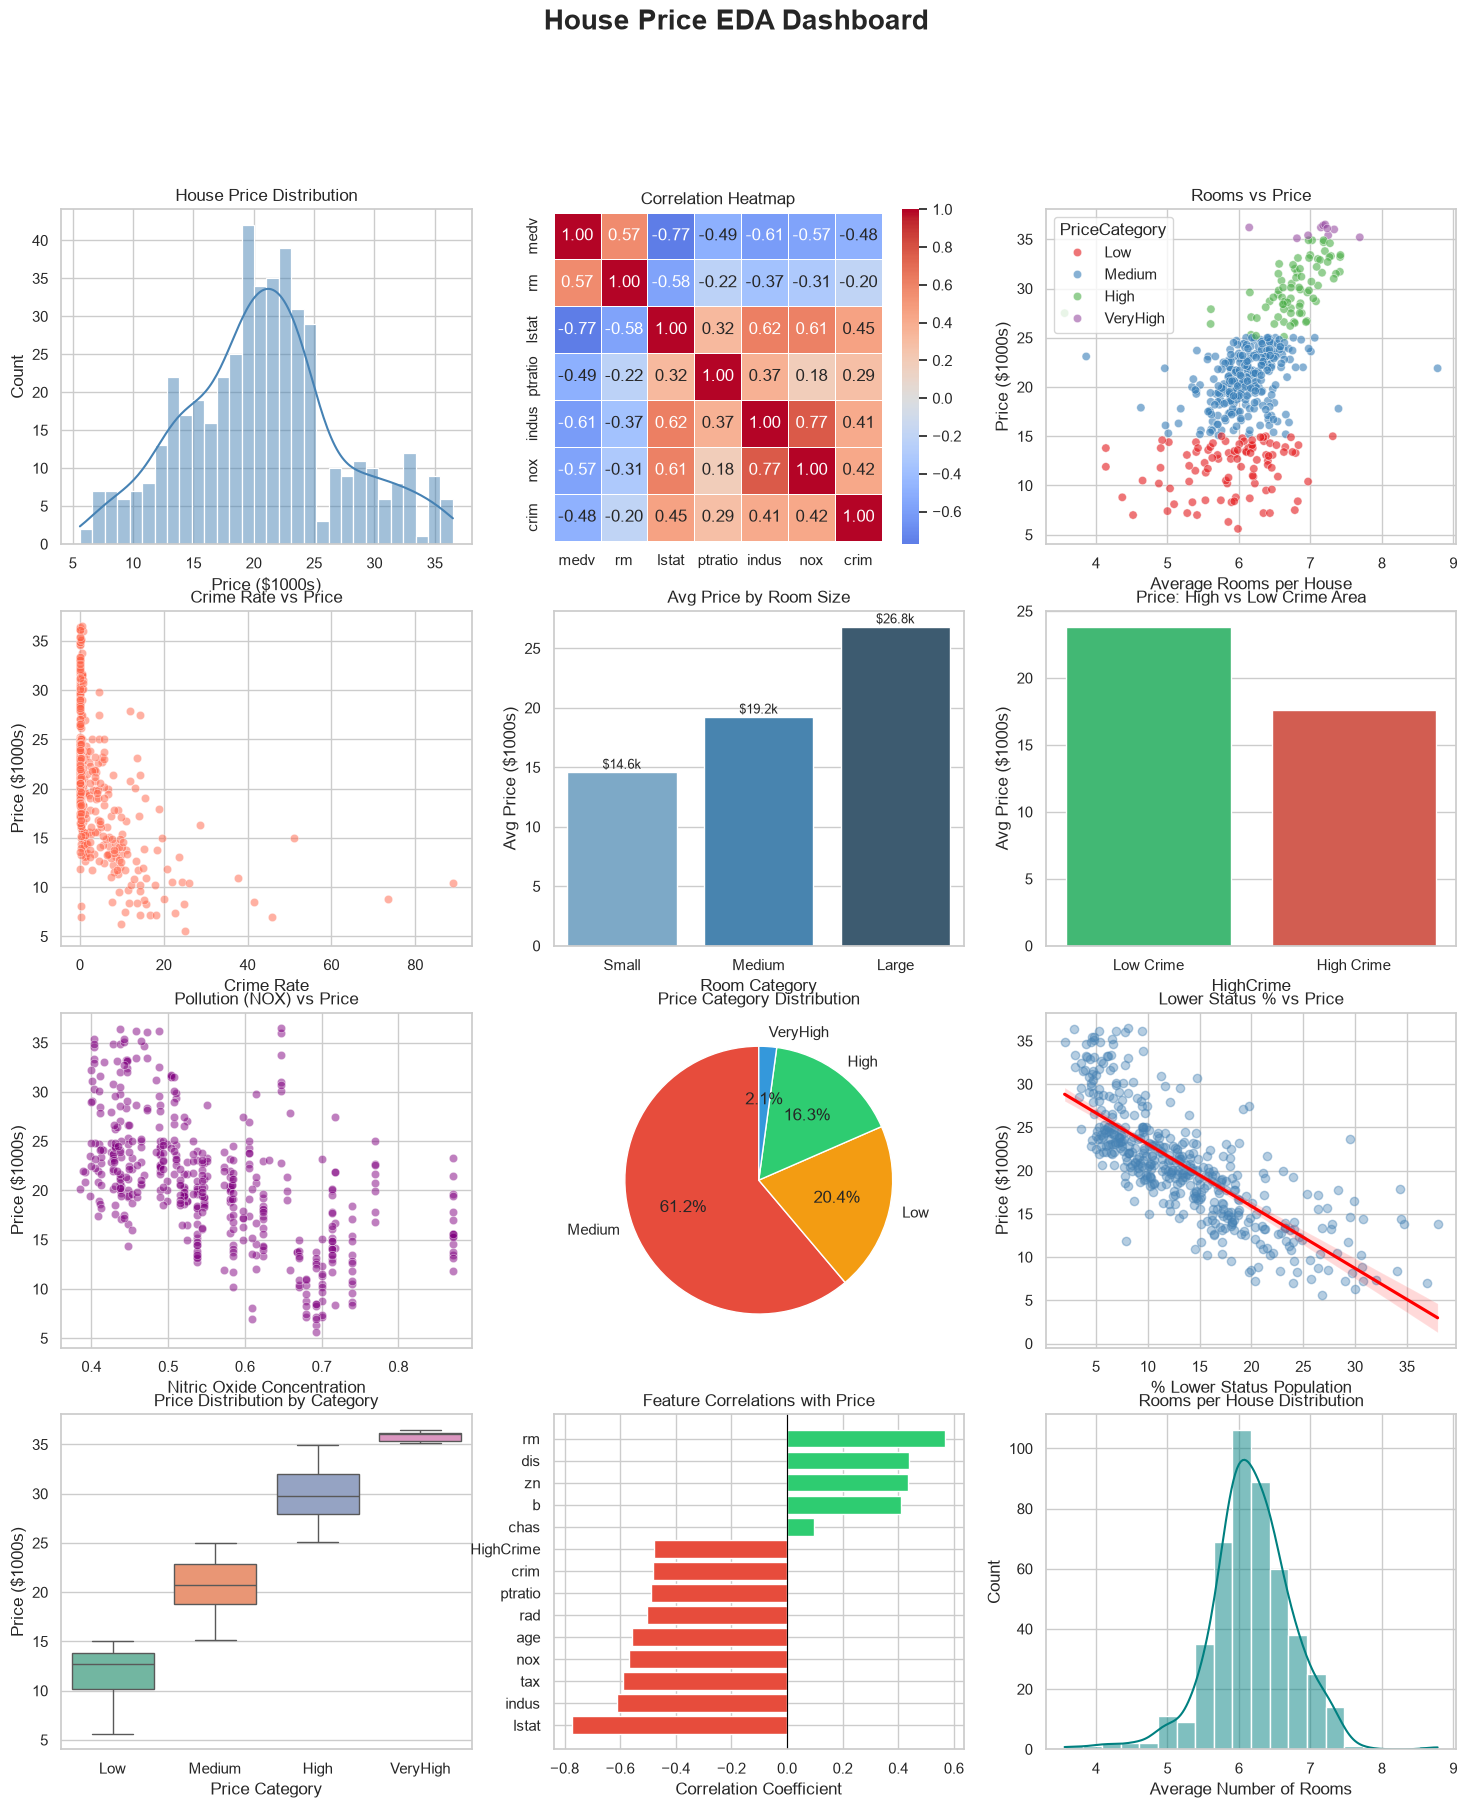

In [ ]:
# ── VISUALIZATIONS ────────────────────────────────────────
#Add all eda visualised charts in a single dashboard to avoid scrolling and confusing
# 12 charts arranged in a 4×3 grid (4 rows, 3 columns)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 20))
fig.suptitle("House Price EDA Dashboard", fontsize=20,
             fontweight="bold", y=0.98)

# Chart 1 — Price Distribution
ax1 = fig.add_subplot(4, 3, 1)
sns.histplot(data=df_clean, x="medv", bins=30,
             kde=True, color="steelblue", ax=ax1)
ax1.set_title("House Price Distribution")
ax1.set_xlabel("Price ($1000s)")

# Chart 2 — Correlation Heatmap
ax2 = fig.add_subplot(4, 3, 2)
top_features = ["medv","rm","lstat","ptratio","indus","nox","crim"]
corr_matrix  = df_clean[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax2)
ax2.set_title("Correlation Heatmap")

# Chart 3 — Rooms vs Price
ax3 = fig.add_subplot(4, 3, 3)
sns.scatterplot(data=df_clean, x="rm", y="medv",
                hue="PriceCategory", palette="Set1",
                alpha=0.6, ax=ax3)
ax3.set_title("Rooms vs Price")
ax3.set_xlabel("Average Rooms per House")
ax3.set_ylabel("Price ($1000s)")

# Chart 4 — Crime vs Price
ax4 = fig.add_subplot(4, 3, 4)
sns.scatterplot(data=df_clean, x="crim", y="medv",
                color="tomato", alpha=0.5, ax=ax4)
ax4.set_title("Crime Rate vs Price")
ax4.set_xlabel("Crime Rate")
ax4.set_ylabel("Price ($1000s)")

# Chart 5 — Price by Room Category
ax5 = fig.add_subplot(4, 3, 5)
room_price = df_clean.groupby("RoomCategory", observed=True)["medv"].mean().reset_index()
sns.barplot(data=room_price, x="RoomCategory", y="medv",
            palette="Blues_d", ax=ax5)
ax5.set_title("Avg Price by Room Size")
ax5.set_xlabel("Room Category")
ax5.set_ylabel("Avg Price ($1000s)")
for i, row in room_price.iterrows():
    ax5.text(i, row["medv"]+0.3, f'${row["medv"]:.1f}k',
             ha="center", fontsize=9)

# Chart 6 — Crime Impact on Price
ax6 = fig.add_subplot(4, 3, 6)
crime_price = df_clean.groupby("HighCrime")["medv"].mean().reset_index()
crime_price["HighCrime"] = crime_price["HighCrime"].map({0:"Low Crime", 1:"High Crime"})
sns.barplot(data=crime_price, x="HighCrime", y="medv",
            palette=["#2ECC71","#E74C3C"], ax=ax6)
ax6.set_title("Price: High vs Low Crime Area")
ax6.set_ylabel("Avg Price ($1000s)")

# Chart 7 — Pollution vs Price
ax7 = fig.add_subplot(4, 3, 7)
sns.scatterplot(data=df_clean, x="nox", y="medv",
                color="purple", alpha=0.5, ax=ax7)
ax7.set_title("Pollution (NOX) vs Price")
ax7.set_xlabel("Nitric Oxide Concentration")
ax7.set_ylabel("Price ($1000s)")

# Chart 8 — Price Category Distribution
ax8 = fig.add_subplot(4, 3, 8)
price_counts = df_clean["PriceCategory"].value_counts()
ax8.pie(price_counts, labels=price_counts.index,
        autopct="%1.1f%%", startangle=90,
        colors=["#E74C3C","#F39C12","#2ECC71","#3498DB"])
ax8.set_title("Price Category Distribution")

# Chart 9 — Lower Status vs Price
ax9 = fig.add_subplot(4, 3, 9)
sns.regplot(data=df_clean, x="lstat", y="medv",
            scatter_kws={"alpha":0.4, "color":"steelblue"},
            line_kws={"color":"red"}, ax=ax9)
ax9.set_title("Lower Status % vs Price")
ax9.set_xlabel("% Lower Status Population")
ax9.set_ylabel("Price ($1000s)")

# Chart 10 — Boxplot Price by Category
ax10 = fig.add_subplot(4, 3, 10)
sns.boxplot(data=df_clean, x="PriceCategory",
            y="medv", palette="Set2",
            order=["Low","Medium","High","VeryHigh"], ax=ax10)
ax10.set_title("Price Distribution by Category")
ax10.set_xlabel("Price Category")
ax10.set_ylabel("Price ($1000s)")

# Chart 11 — Top Correlations Bar
ax11 = fig.add_subplot(4, 3, 11)
corr_target = df_clean.corr(numeric_only=True)["medv"].drop("medv").sort_values()
colors       = ["#E74C3C" if x < 0 else "#2ECC71" for x in corr_target]
ax11.barh(corr_target.index, corr_target.values, color=colors)
ax11.set_title("Feature Correlations with Price")
ax11.set_xlabel("Correlation Coefficient")
ax11.axvline(x=0, color="black", linewidth=0.8)

# Chart 12 — Rooms Distribution
ax12 = fig.add_subplot(4, 3, 12)
sns.histplot(data=df_clean, x="rm", bins=20,
             kde=True, color="teal", ax=ax12)
ax12.set_title("Rooms per House Distribution")
ax12.set_xlabel("Average Number of Rooms")


In [13]:

plt.tight_layout()
plt.savefig("house_prices_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved!")

<Figure size 640x480 with 0 Axes>

Dashboard saved!


In [14]:
# ── INSIGHTS SUMMARY ──────────────────────────────────────

# Print key findings in plain English
print("="*55)
print("KEY INSIGHTS — HOUSE PRICES")
print("="*55)
print(f"Dataset size:         {df_clean.shape[0]} houses")
print(f"Average price:        ${df_clean['medv'].mean():.1f}k")
print(f"Price range:          ${df_clean['medv'].min():.1f}k – ${df_clean['medv'].max():.1f}k")
print(f"\nStrongest positive:   rm (rooms)     {corr['rm']:.3f}")
print(f"Strongest negative:   lstat          {corr['lstat']:.3f}")
print(f"\nHigh crime avg price: ${df_clean[df_clean['HighCrime']==1]['medv'].mean():.1f}k")
print(f"Low crime avg price:  ${df_clean[df_clean['HighCrime']==0]['medv'].mean():.1f}k")
print(f"\nLarge rooms avg:      ${df_clean[df_clean['RoomCategory']=='Large']['medv'].mean():.1f}k")
print(f"Small rooms avg:      ${df_clean[df_clean['RoomCategory']=='Small']['medv'].mean():.1f}k")

KEY INSIGHTS — HOUSE PRICES
Dataset size:         466 houses
Average price:        $20.7k
Price range:          $5.6k – $36.5k

Strongest positive:   rm (rooms)     0.569
Strongest negative:   lstat          -0.772

High crime avg price: $17.6k
Low crime avg price:  $23.8k

Large rooms avg:      $26.8k
Small rooms avg:      $14.6k
